In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier
import joblib

In [14]:
df = pd.read_csv("./AAPL.csv")
df = df.sort_values("Date").reset_index(drop=True)

In [15]:
df["return"] = df["Close"].pct_change()
df["log_return"] = np.log(df["Close"]).diff()

df["MA5"] = df["Close"].rolling(5).mean()
df["MA10"] = df["Close"].rolling(10).mean()
df["MA20"] = df["Close"].rolling(20).mean()

df["dist_MA5"] = (df["Close"] - df["MA5"]) / df["MA5"]
df["dist_MA10"] = (df["Close"] - df["MA10"]) / df["MA10"]
df["dist_MA20"] = (df["Close"] - df["MA20"]) / df["MA20"]

df["volatility"] = df["return"].rolling(10).std()
df["price_range"] = (df["High"] - df["Low"]) / df["Close"]

for i in range(1, 6):
    df[f"lag_return_{i}"] = df["return"].shift(i)


def rsi(series, period=14):
    delta = series.diff()

    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()

    rs = gain / (loss + 1e-9)

    return 100 - (100 / (1 + rs))


df["rsi_14"] = rsi(df["Close"])

bb_mid = df["Close"].rolling(20).mean()
bb_std = df["Close"].rolling(20).std()

df["bb_pos"] = (
    (df["Close"] - (bb_mid - 2 * bb_std))
    / (4 * bb_std + 1e-9)
)

df["vol_ratio"] = (
    df["Volume"]
    / df["Volume"].rolling(20).mean()
)

df["future_return"] = (
    df["Close"].shift(-1) / df["Close"] - 1
)

df["Target_Class"] = (
    df["future_return"] > 0
).astype(int)

df["Target_Price"] = df["Close"].shift(-1)

df = df.dropna().reset_index(drop=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9889 entries, 0 to 9888
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9889 non-null   object 
 1   Open           9889 non-null   float64
 2   High           9889 non-null   float64
 3   Low            9889 non-null   float64
 4   Close          9889 non-null   float64
 5   Adj Close      9889 non-null   float64
 6   Volume         9889 non-null   int64  
 7   return         9889 non-null   float64
 8   log_return     9889 non-null   float64
 9   MA5            9889 non-null   float64
 10  MA10           9889 non-null   float64
 11  MA20           9889 non-null   float64
 12  dist_MA5       9889 non-null   float64
 13  dist_MA10      9889 non-null   float64
 14  dist_MA20      9889 non-null   float64
 15  volatility     9889 non-null   float64
 16  price_range    9889 non-null   float64
 17  lag_return_1   9889 non-null   float64
 18  lag_retu

In [17]:
features = [
    "return",
    "log_return",
    "dist_MA5",
    "dist_MA10",
    "dist_MA20",
    "volatility",
    "price_range",
    "lag_return_1",
    "lag_return_2",
    "lag_return_3",
    "lag_return_4",
    "lag_return_5",
    "rsi_14",
    "bb_pos",
    "vol_ratio"
]

split = int(len(df) * 0.8)

scaler = StandardScaler()

scaler.fit(df[features].iloc[:split])

scaled_features = scaler.transform(df[features])

In [18]:
print(df["Target_Class"].value_counts(normalize=True))

Target_Class
0    0.506522
1    0.493478
Name: proportion, dtype: float64


In [19]:
def create_dual_sequences(
    X_features,
    raw_prices,
    target_classes,
    target_prices,
    lookback=30
):
    X_class = []
    y_class = []
    X_price = []
    y_price = []
    scales = []
    for i in range(lookback, len(X_features)):
        X_class.append(X_features[i - lookback:i])
        y_class.append(target_classes[i])
        window = raw_prices[i - lookback:i]
        w_min = window.min()
        w_max = window.max()
        if w_max == w_min:
            w_max += 1e-8
        scaled_window = (
            (window - w_min)
            / (w_max - w_min)
        )
        scaled_target = (
            (target_prices[i] - w_min)
            / (w_max - w_min)
        )
        X_price.append(scaled_window)
        y_price.append(scaled_target)
        scales.append((w_min, w_max))
    return (
        np.array(X_class),
        np.array(y_class),
        np.array(X_price),
        np.array(y_price),
        np.array(scales)
    )

X_seq_c, y_seq_c, X_seq_p, y_seq_p, scales = (
    create_dual_sequences(
        scaled_features,
        df["Close"].values,
        df["Target_Class"].values,
        df["Target_Price"].values
    )
)

split_seq = int(len(X_seq_c) * 0.8)

In [20]:
X_train_c = X_seq_c[:split_seq]
X_test_c  = X_seq_c[split_seq:]

y_train_c = y_seq_c[:split_seq]
y_test_c  = y_seq_c[split_seq:]

X_train_p = X_seq_p[:split_seq]
X_test_p  = X_seq_p[split_seq:]

y_train_p = y_seq_p[:split_seq]
y_test_p  = y_seq_p[split_seq:]

scales_test = scales[split_seq:]

X_train_p = X_train_p.reshape(
    X_train_p.shape[0],
    X_train_p.shape[1],
    1
)

X_test_p = X_test_p.reshape(
    X_test_p.shape[0],
    X_test_p.shape[1],
    1
)

actual_test_prices = (df["Target_Price"].values[30 + split_seq:])

In [21]:
direction_model = keras.Sequential([
    keras.Input(shape=(X_train_c.shape[1],X_train_c.shape[2])),
    layers.LSTM(32),
    layers.Dropout(0.4),
    layers.Dense(1,activation="sigmoid")
])

direction_model.compile(
    optimizer=Adam(0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
price_model = keras.Sequential([
    keras.Input(shape=(X_train_p.shape[1],1)),
    layers.LSTM(32),
    layers.Dropout(0.1),
    layers.Dense(1)
])

price_model.compile(
    optimizer=Adam(0.001),
    loss="mse"
)

In [22]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_c),
    y=y_train_c
)

class_weight_dict = dict(
    enumerate(class_weights)
)

es = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

direction_model.fit(
    X_train_c,
    y_train_c,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_c, y_test_c),
    shuffle=False,
    callbacks=[es],
    class_weight=class_weight_dict
)

price_model.fit(
    X_train_p,
    y_train_p,
    epochs=15,
    batch_size=32,
    validation_data=(X_test_p, y_test_p),
    shuffle=False,
    callbacks=[es]
)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.5044 - loss: 0.7003 - val_accuracy: 0.5203 - val_loss: 0.6944
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.5209 - loss: 0.6958 - val_accuracy: 0.5269 - val_loss: 0.6942
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5152 - loss: 0.6938 - val_accuracy: 0.5223 - val_loss: 0.6934
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5282 - loss: 0.6923 - val_accuracy: 0.5294 - val_loss: 0.6938
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5297 - loss: 0.6902 - val_accuracy: 0.5243 - val_loss: 0.6940
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5282 - loss: 0.6915 - val_accuracy: 0.5264 - val_loss: 0.6937
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5286 - loss: 0.6900 - val_accuracy: 0.5304 - val_loss: 0.6943
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5361 - loss: 0.6894 - val_acc

In [71]:
y_prob = direction_model.predict(X_test_c).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_price_scaled = price_model.predict(X_test_p).flatten()
y_price = np.array([y_price_scaled[i] *(scales_test[i][1] - scales_test[i][0])+ scales_test[i][0]for i in range(len(y_price_scaled))])
current_prices = df["Close"].values[30 + split_seq:]
price_move_pct = np.abs(y_price - current_prices) / current_prices
price_direction = (y_price > current_prices).astype(int)
agreement = (price_direction == y_pred).astype(int)
direction_confidence = (np.abs(y_prob - 0.5) * 2)
predicted_return = (y_price - current_prices) / current_prices
vol_factor = np.ones_like(y_prob)
reliability_features = pd.DataFrame({
    "direction_prob": y_prob,
    "agreement": agreement,
    "move_strength": np.clip(price_move_pct * 20, 0, 1),
    "vol_factor": vol_factor,
    "direction_conf": direction_confidence,
    "predicted_return": predicted_return
})

reliability_target = (y_pred == y_test_c).astype(int)
rel_split = int(len(reliability_features) * 0.7)
xgb_reliability = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss"
)
xgb_reliability.fit(reliability_features.iloc[:rel_split],
                    reliability_target[:rel_split])
reliability_score = xgb_reliability.predict_proba(
    reliability_features)[:, 1] * 100

top20 = reliability_score >= np.percentile(
    reliability_score,
    80
)

bottom20 = reliability_score <= np.percentile(
    reliability_score,
    20
)

print(
    "Top20 Accuracy:",
    accuracy_score(
        y_test_c[top20],
        y_pred[top20]
    )
)

print(
    "Bottom20 Accuracy:",
    accuracy_score(
        y_test_c[bottom20],
        y_pred[bottom20]
    )
)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Top20 Accuracy: 0.7189873417721518
Bottom20 Accuracy: 0.29873417721518986


In [49]:
print( "Accuracy:",accuracy_score(y_test_c,y_pred))
print("ROC-AUC:",roc_auc_score(y_test_c,y_prob))
print("MCC:",matthews_corrcoef(y_test_c,y_pred))
print("MAE:",mean_absolute_error(actual_test_prices,y_price))

print("RMSE:",np.sqrt(mean_squared_error(actual_test_prices,y_price)))
print("R2:",r2_score(actual_test_prices,y_price))
print("Average Reliability:",reliability_score.mean())
print("Maximum Reliability:",reliability_score.max(),2)

Accuracy: 0.5223123732251521
ROC-AUC: 0.5149193984637023
MCC: 0.01938776794779683
MAE: 2.318043291394824
RMSE: 3.7195990525906306
R2: 0.9958515242541853
Average Reliability: 52.084637
Maximum Reliability: 75.62674 2


In [50]:
def reliability_label(score):
    if score >= 80:
        return "Very High"
    elif score >= 60:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"


labels = [reliability_label(x) for x in reliability_score]

In [51]:
print("===== RELIABILITY ANALYSIS =====")

print(
    "Average Reliability:",
    round(np.mean(reliability_score), 2)
)

print(
    "Max Reliability:",
    round(np.max(reliability_score), 2)
)

print(
    "Min Reliability:",
    round(np.min(reliability_score), 2)
)

===== RELIABILITY ANALYSIS =====
Average Reliability: 52.08
Max Reliability: 75.63
Min Reliability: 21.96


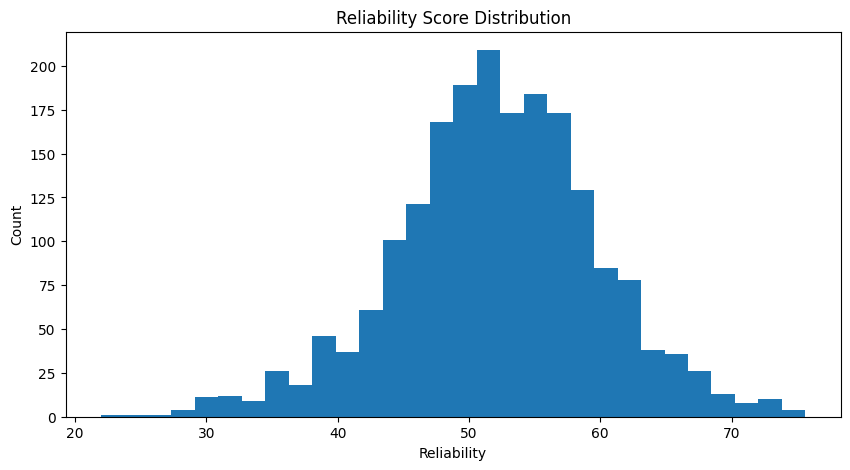

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    reliability_score,
    bins=30
)

plt.title("Reliability Score Distribution")
plt.xlabel("Reliability")
plt.ylabel("Count")

plt.show()

In [70]:
joblib.dump(scaler,"scaler.pkl")
direction_model.save("direction.keras")
price_model.save("price.keras")
joblib.dump(xgb_reliability, "xgb_reliability_model.pkl")
print("Saved successfully")

Saved successfully


In [64]:

latest_features = scaled_features[-30:]
latest_features = latest_features.reshape(1, 30, len(features))

latest_price_window = df["Close"].values[-30:]

w_min = latest_price_window.min()
w_max = latest_price_window.max()

latest_price_scaled = (
    (latest_price_window - w_min)
    / (w_max - w_min)
)

latest_price_scaled = latest_price_scaled.reshape(1, 30, 1)

direction_prob = direction_model.predict(
    latest_features,
    verbose=0
)[0][0]

direction_model_text = (
    "UP"
    if direction_prob > 0.5
    else "DOWN"
)

pred_scaled_price = price_model.predict(
    latest_price_scaled,
    verbose=0
)[0][0]

pred_price = (
    pred_scaled_price * (w_max - w_min)
    + w_min
)

current_price = df["Close"].iloc[-1]

price_direction_text = (
    "UP"
    if pred_price > current_price
    else "DOWN"
)

price_move_pct = abs(
    pred_price - current_price
) / current_price

price_direction = int(
    pred_price > current_price
)

direction_class = int(
    direction_prob > 0.5
)

agreement = int(
    price_direction == direction_class
)
predicted_return = (
    pred_price - current_price
) / current_price

vol_factor = 1.0
direction_conf = abs(
    direction_prob - 0.5
) * 2

rel_features = pd.DataFrame({
    "direction_prob": [direction_prob],
    "agreement": [agreement],
    "move_strength": [np.clip(price_move_pct * 20, 0, 1)],
    "vol_factor": [vol_factor],
    "direction_conf": [direction_conf],
    "predicted_return": [predicted_return]
})

reliability = (
    xgb_reliability.predict_proba(rel_features)[0][1]
    * 100
)

def reliability_label(score):
    if score >= 80:
        return "Very High"
    elif score >= 60:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"

print("========== AI FORECAST ==========")
print(f"Current Price      : ${current_price:.2f}")
print(f"Predicted Price    : ${pred_price:.2f}")
print(f"Price Model Move   : {price_direction_text}")
print(f"Direction Model    : {direction_model_text}")
print(f"Direction Prob     : {direction_prob:.3f}")
print(f"Reliability Score  : {reliability:.2f}/100")
print(f"Reliability Label  : {reliability_label(reliability)}")

if agreement == 0:
    print("🔴 HIGH RISK: Models disagree. No trade.")
elif reliability >= 62:
    print(f"🟢 LOW RISK: ORDER APPROVED — {direction_model_text}")
elif reliability >= 48:
    print(f"🟡 MEDIUM RISK: Proceed with caution — {direction_model_text}")
else:
    print("🔴 HIGH RISK: Low confidence. No trade.")

========== AI FORECAST ==========
Current Price      : $254.29
Predicted Price    : $256.08
Price Model Move   : UP
Direction Model    : DOWN
Direction Prob     : 0.444
Reliability Score  : 58.85/100
Reliability Label  : Medium
🔴 HIGH RISK: Models disagree. No trade.
